# Multimodal ICU Mortality Prediction

This work aims to provide a tool to estimate what the death risk is for a patient that's been just admitted in the ICU. We're therefore including data that spans from 24 hours before ICU admission (**NOT hospital admission**) to the moment of ICU admission. We predict in-hospital mortality at T=0 where T=0 is **ICU admission** (mimiciv_icu.icustays, intime column) based on all the data available to that moment.

The model is intended to be used on early ICU admission and its goal should be to help correctly prioritize resources that are usually not extensive as far as ICUs are concerned.


General rules:

* We'll be taking into account only the **first ICU admission** per patient, to avoid temporal leakage.
* In case of multiple X-rays, the closest to admission is analyzed.
* To extract the date an X-ray was taken the `study_time` field will be used, not the report timestamp.
* charttime will be used to place lab events and similar in time.
* We're not considering admission diagnosis, both because they're sometimes added later and because of human error

In [1]:
%set_env DUCKDB_DB_PATH=../mimic-iv/mimic4.duckdb
%set_env CXR_ROOT=../mimic-cxr/physionet.org/files/mimic-cxr/2.1.0
%set_env CXR_JPG_ROOT=../mimic-cxr-jpg/physionet.org/files/mimic-cxr-jpg/2.1.0
# Yes, it ships with CXR-JPG
%set_env CXR_METADATA_FILE=../mimic-cxr-jpg/physionet.org/files/mimic-cxr-jpg/2.1.0/mimic-cxr-2.0.0-metadata.csv
%set_env COHORT_IMAGES_MANIFEST=./cohort_images_manifest.csv

env: DUCKDB_DB_PATH=../mimic-iv/mimic4.duckdb
env: CXR_ROOT=../mimic-cxr/physionet.org/files/mimic-cxr/2.1.0
env: CXR_JPG_ROOT=../mimic-cxr-jpg/physionet.org/files/mimic-cxr-jpg/2.1.0
env: CXR_METADATA_FILE=../mimic-cxr-jpg/physionet.org/files/mimic-cxr-jpg/2.1.0/mimic-cxr-2.0.0-metadata.csv
env: COHORT_IMAGES_MANIFEST=./cohort_images_manifest.csv


WARNING: tables starting with mimic_ are legacy and contain no data

In [2]:
! duckdb --readonly $DUCKDB_DB_PATH ".tables"

caregiver                        mimiciv_hosp.admissions        
diagnosis                        mimiciv_hosp.d_hcpcs           
edstays                          mimiciv_hosp.d_icd_diagnoses   
ingredientevents                 mimiciv_hosp.d_icd_procedures  
medrecon                         mimiciv_hosp.d_labitems        
mimic_core.admissions            mimiciv_hosp.diagnoses_icd     
mimic_core.patients              mimiciv_hosp.drgcodes          
mimic_core.transfers             mimiciv_hosp.emar              
mimic_hosp.d_hcpcs               mimiciv_hosp.emar_detail       
mimic_hosp.d_icd_diagnoses       mimiciv_hosp.hcpcsevents       
mimic_hosp.d_icd_procedures      mimiciv_hosp.labevents         
mimic_hosp.d_labitems            mimiciv_hosp.microbiologyevents
mimic_hosp.diagnoses_icd         mimiciv_hosp.patients          
mimic_hosp.drgcodes              mimiciv_hosp.pharmacy          
mimic_hosp.emar                  mimiciv_hosp.poe               
mimic_hosp.emar_detail   

In [3]:
import os
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import duckdb
import pydicom

In [4]:
dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

In [5]:
dconn.execute("SELECT subject_id, dod FROM mimiciv_hosp.patients WHERE dod IS NOT NULL LIMIT 10;").fetchdf(date_as_object=True)
dconn.close()

Focusing on patients 10000032 and 10000935 who actually had chest X-ray

In [6]:
xray_patient_dirs = [ f'{os.getenv('CXR_ROOT')}/files/p10/p10000032', f'{os.getenv('CXR_ROOT')}/files/p10/p10000935' ]

In [7]:
dcm_files = [p for d in xray_patient_dirs for p in Path(d).glob('**/*.dcm')]

In [8]:
patients = {}

for f in dcm_files:
  content = pydicom.dcmread(f)
  study_date = content.get("StudyDate", "None")
  study_time = content.get("StudyTime", "None")
  patient_id = content.get("PatientID", "None")

  image = content.pixel_array
  if not patient_id in patients:
    patients[patient_id] = {}
    patients[patient_id][study_date] = []
  else:
       if not study_date in patients[patient_id]:
            patients[patient_id][study_date] = []

  patients[patient_id][study_date].append({'study_time': study_time, 'image': image})
  


==> Patient: 10000032
=> Study 21800506 | 2 images.
=> Study 21800626 | 2 images.
=> Study 21800805 | 1 images.
=> Study 21800723 | 2 images.
==> Patient: 10000935
=> Study 21870711 | 2 images.
=> Study 21860730 | 2 images.
=> Study 21871016 | 1 images.
=> Study 21870226 | 2 images.
=> Study 21871010 | 1 images.
=> Study 21870823 | 2 images.


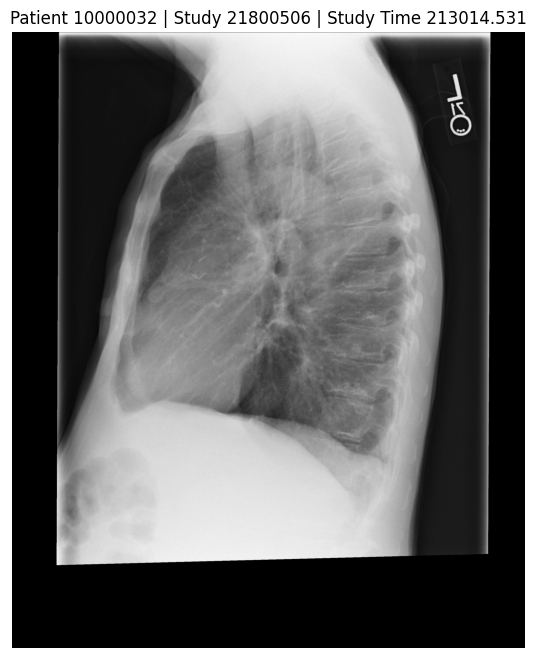

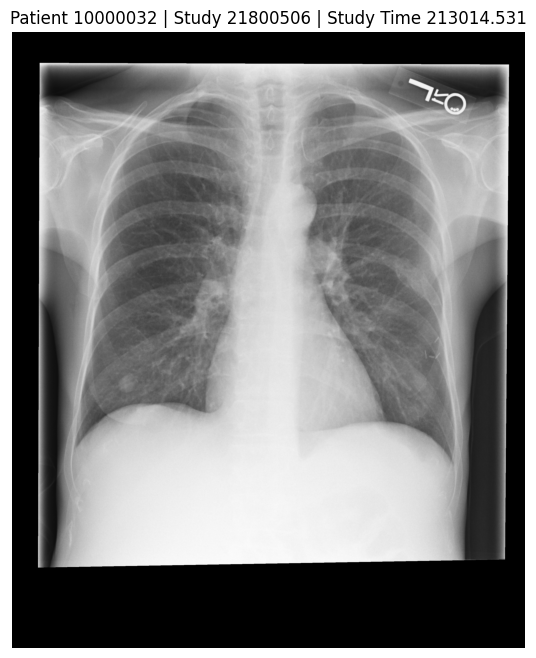

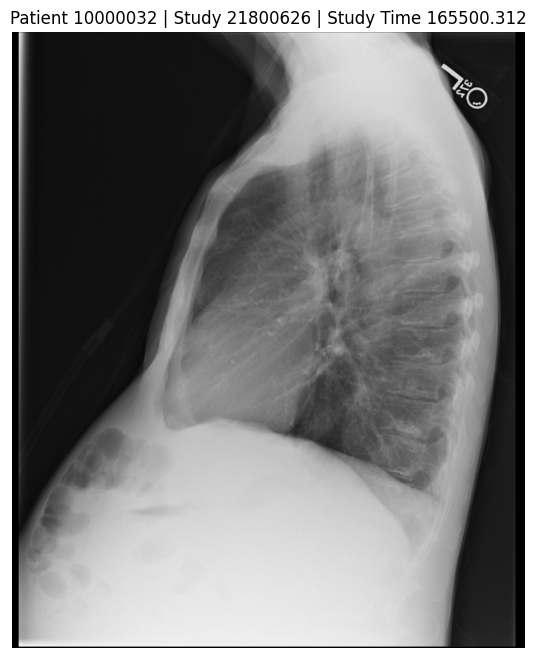

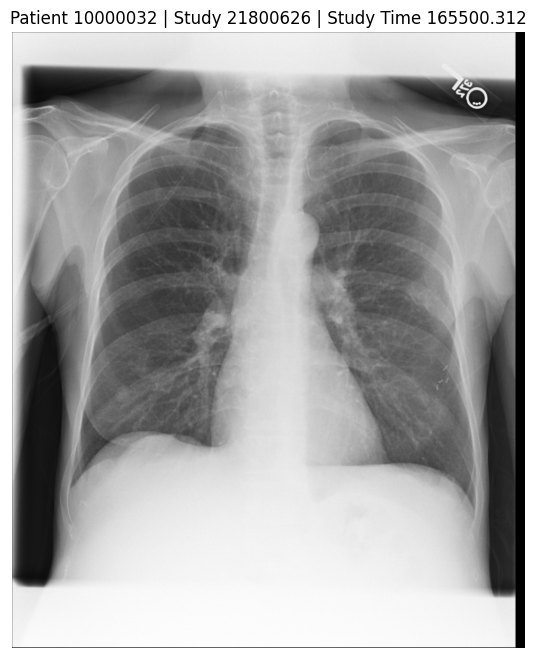

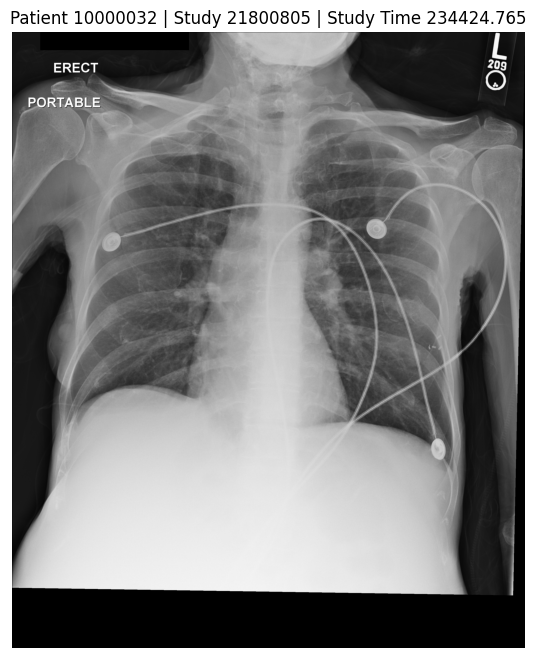

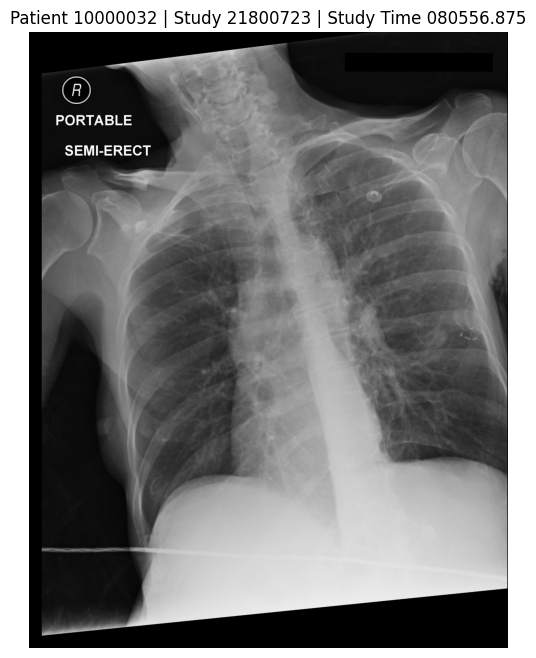

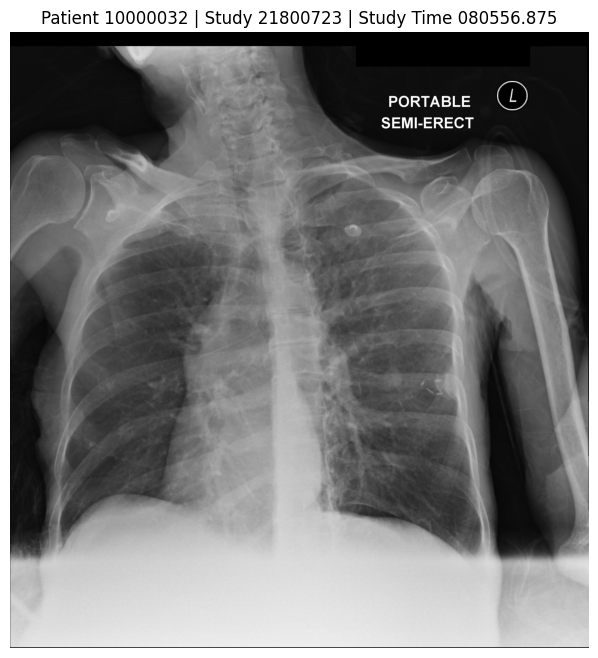

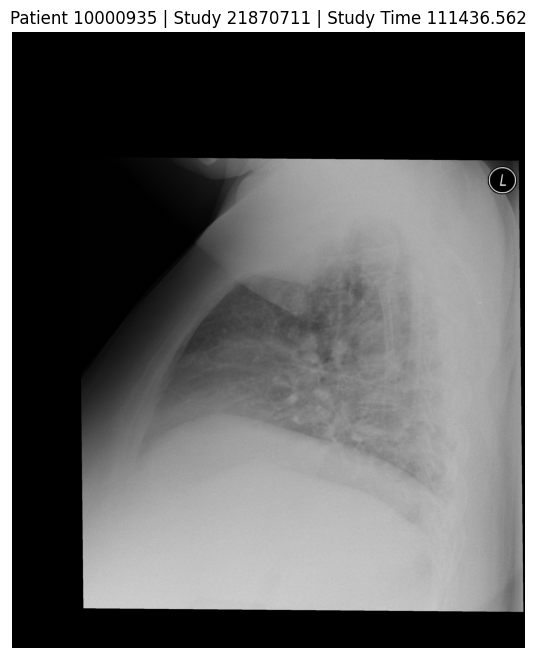

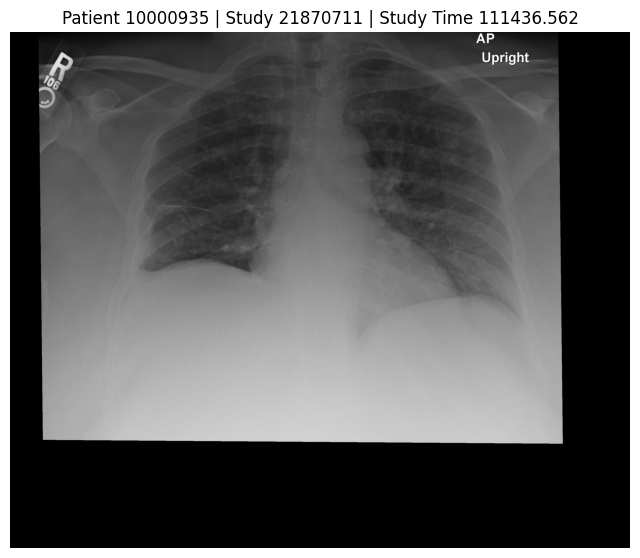

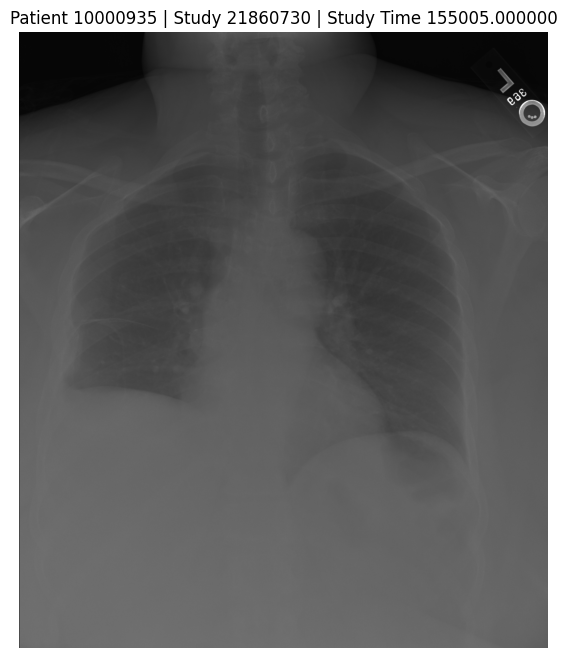

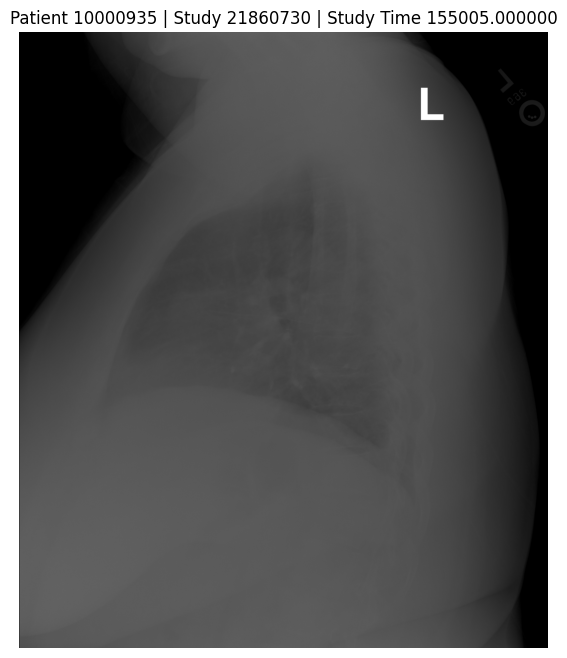

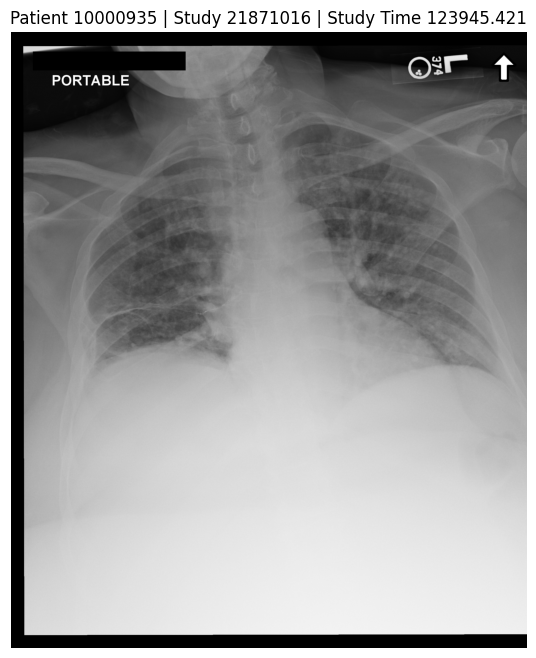

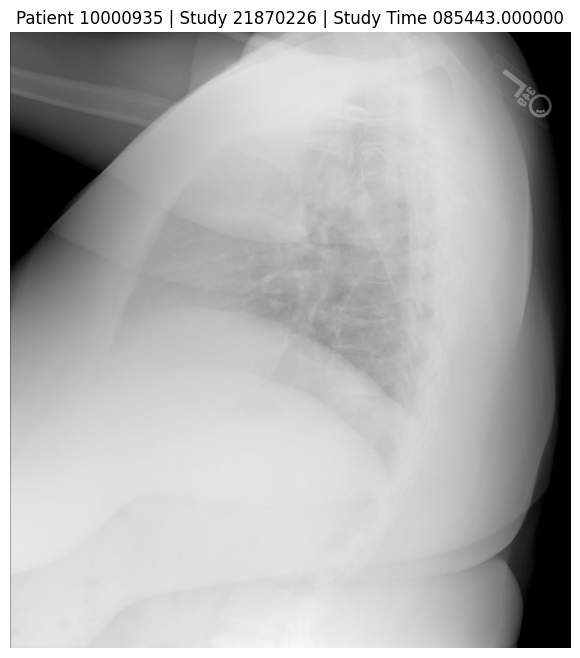

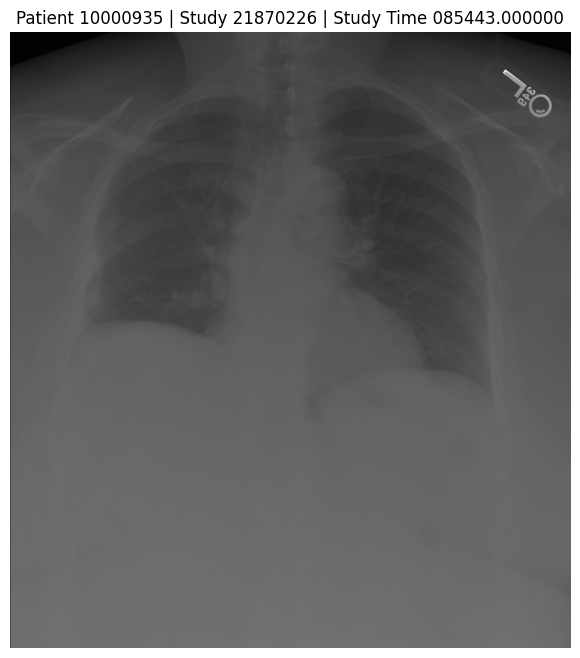

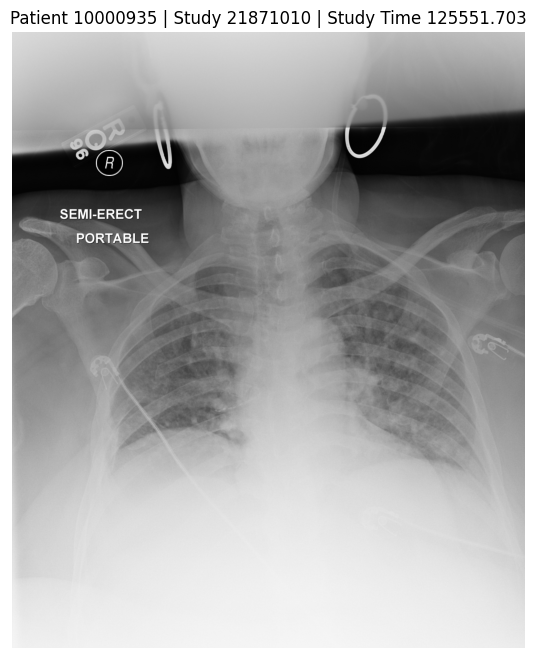

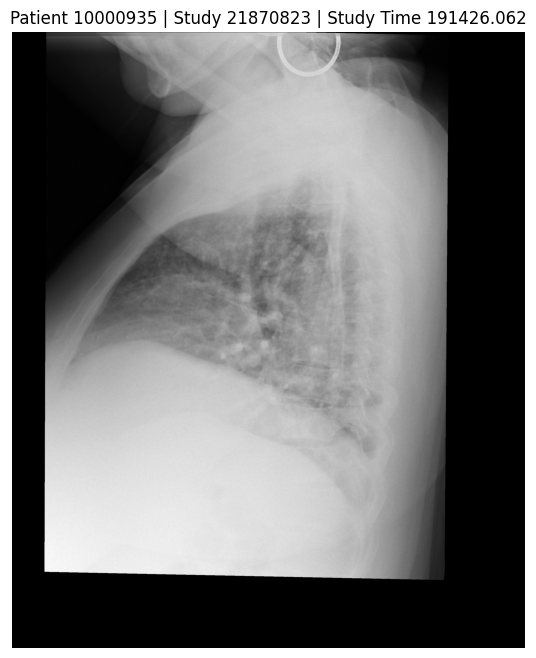

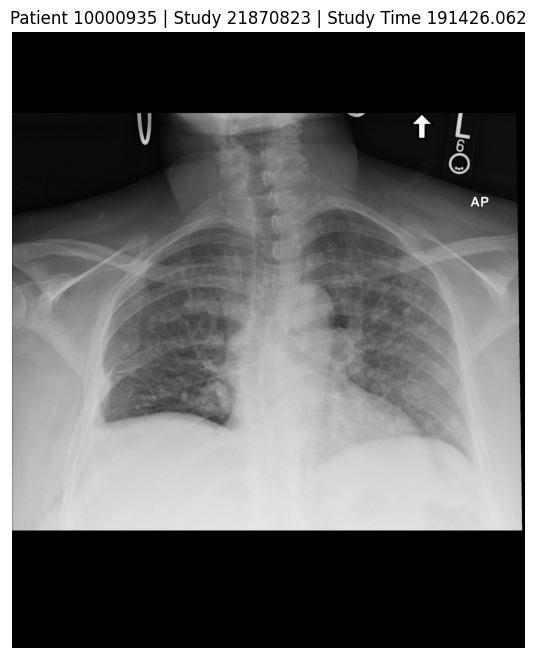

In [9]:
for patient_id, studies in patients.items():
  print(f'==> Patient: {patient_id}')
  for study_date, study_materials in studies.items():
      print(f'=> Study {study_date} | {len(study_materials)} images.')
      for material in study_materials:
           plt.figure(figsize=(8, 8))
           plt.imshow(material['image'], cmap='grey')
           plt.axis('off')
           plt.title(f'Patient {patient_id} | Study {study_date} | Study Time {material['study_time']}')

	

In [10]:
# get unique study times
valid_timestamps: list[dict[str, datetime]] = []
already_recorded = set()
for patient_id, studies in patients.items():
  for study_day, materials_list in studies.items():
    for item in materials_list:
      # E.g.: 191426 => 19:14:26
      study_time = item['study_time'][:6] # excluding fractional second
      # Combine with study day
      timestamp = datetime.strptime(f'{study_day} {study_time}', "%Y%m%d %H%M%S")
      if timestamp in already_recorded:
        continue
      else:
        already_recorded.add(timestamp)
        entry = {'patient_id': patient_id, 'timestamp': timestamp}
        valid_timestamps.append(entry)
		



In [11]:
timestamps_df = pd.DataFrame(valid_timestamps)
timestamps_df

,patient_id,timestamp
0,10000032,2180-05-06 21:30:14
1,10000032,2180-06-26 16:55:00
2,10000032,2180-08-05 23:44:24
3,10000032,2180-07-23 08:05:56
4,10000935,2187-07-11 11:14:36
5,10000935,2186-07-30 15:50:05
6,10000935,2187-10-16 12:39:45
7,10000935,2187-02-26 08:54:43
8,10000935,2187-10-10 12:55:51
9,10000935,2187-08-23 19:14:26


In [12]:
# Check https://duckdb.org/docs/current/clients/python/data_ingestion#directly-accessing-dataframes-and-arrow-objects and its awesomeness!
# DuckDB can access arrow-based structures like pandas and polars dataframes

dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

# Return data for subjects whose id is in the dataframe and had a chest X-Ray
# within the first 24h in the ICU or in the preceding 24h

join_query = """
SELECT
	i.subject_id,
	i.stay_id,
  	i.intime
FROM mimiciv_icu.icustays AS i
INNER JOIN timestamps_df as t
	ON CAST(i.subject_id AS VARCHAR) = CAST(t.patient_id AS VARCHAR)
    AND (t.timestamp >= (i.intime - INTERVAL 24 HOURS) AND t.timestamp <= (i.intime + INTERVAL 24 HOURS))
"""


results = dconn.query(join_query).fetchall()
print(results)

dconn.close()

[(10000032, 39553978, datetime.datetime(2180, 7, 23, 14, 0))]


## Early exploration

Patient 10000032
```SQL
SELECT intime, subject_id
FROM mimiciv_icu.icustays
WHERE subject_id = 10000032
ORDER BY intime ASC
```
They were admitted in ICU at 2180-07-23 14:00:00. X-Ray timestamp reports 2180-07-23 08:05:56, which was before the ICU admission.


Patient 10000935
```SQL
SELECT intime, subject_id
FROM mimiciv_icu.icustays
WHERE subject_id = 10000935
ORDER BY intime ASC
```
Returned nothing, the patient was never admitted to ICU it seems.

In [13]:
! duckdb :memory: "DESCRIBE TABLE \"$CXR_METADATA_FILE\";"

┌────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │ column_type │  null   │   key   │ default │  extra  │
│        varchar         │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ dicom_id               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ subject_id             │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ study_id               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ PerformedProcedureSt…  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ViewPosition           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Rows                   │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Columns                │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ StudyDate              │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ StudyTime              │ D

In [14]:
! duckdb :memory: "SELECT subject_id, StudyDate, StudyTime FROM \"$CXR_METADATA_FILE\" LIMIT 10;"

┌────────────┬───────────┬────────────────────┐
│ subject_id │ StudyDate │     StudyTime      │
│   int64    │   int64   │       double       │
├────────────┼───────────┼────────────────────┤
│   10000032 │  21800506 │ 213014.53100000002 │
│   10000032 │  21800506 │ 213014.53100000002 │
│   10000032 │  21800626 │         165500.312 │
│   10000032 │  21800626 │         165500.312 │
│   10000032 │  21800723 │          80556.875 │
│   10000032 │  21800723 │          80556.875 │
│   10000032 │  21800805 │         234424.765 │
│   10000764 │  21321015 │          84047.984 │
│   10000764 │  21321015 │          84047.984 │
│   10000764 │  21321015 │          84047.984 │
├────────────┴───────────┴────────────────────┤
│ 10 rows                           3 columns │
└─────────────────────────────────────────────┘


## Which ICU patients have had an X-Ray in the previous 24 hours?

In [15]:
# Cannot cast StudyTime to string directly: even ignoring the decimal part 80556.875 would become "80556" while the %H format needs 08 for the hour, not 8
# I'm overriding duckdb's inferred type and handle

# Also, duckdb arrays ara 1-based, not 0-based!!

# 1. Parse the metadata file from cxr-jpg that contains the DICOM metadata xcr puts in the DICOM files themselves (only need subject_id, dicom_id and the synthetic cxr_time)
# 2. Select only the patients that took an X-Ray either in the +-24H range or in the 24H before admission
stays_previous_24h = f"""
WITH cxr_meta_parsed AS (
	SELECT
		subject_id,
		dicom_id,
		strptime (
			StudyDate || ' ' || lpad(string_split(StudyTime, '.')[1], 6, '0'),
			'%Y%m%d %H%M%S'
		) as cxr_time
    FROM read_csv_auto(
		'{os.getenv('CXR_METADATA_FILE')}',
		types={{'StudyDate': 'VARCHAR', 'StudyTime': 'VARCHAR'}},
		quote='"'
  	)
)
SELECT DISTINCT i.subject_id
FROM mimiciv_icu.icustays AS i
INNER JOIN cxr_meta_parsed as c
	ON i.subject_id = c.subject_id
	AND (c.cxr_time >= (i.intime - INTERVAL 24 HOURS)) AND (c.cxr_time <= i.intime)

"""

dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

minus_24 = dconn.query(stays_previous_24h).df()
dconn.close()

print(f'Patients that took an X-ray in the 24h preceeding admission: {len(minus_24)}')


Patients that took an X-ray in the 24h preceeding admission: 9764


In [16]:
! duckdb :memory: "DESCRIBE TABLE \"$CXR_METADATA_FILE\";"

┌────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │ column_type │  null   │   key   │ default │  extra  │
│        varchar         │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ dicom_id               │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ subject_id             │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ study_id               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ PerformedProcedureSt…  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ViewPosition           │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ Rows                   │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ Columns                │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ StudyDate              │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ StudyTime              │ D

In [17]:
# Query for showing numbered stays for each patient

stays_by_patient = f"""
WITH stays_by_patient AS (
	SELECT
		subject_id,
		stay_id,
		intime,
		row_number() OVER(PARTITION BY subject_id ORDER BY intime ASC) as stay_number
    FROM mimiciv_icu.icustays
)
SELECT * FROM stays_by_patient;
"""

dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)
result = dconn.query(stays_by_patient).df()
print(result.head())

print("Done.")
dconn.close()


   subject_id   stay_id              intime  stay_number
0    17232262  39561273 2179-04-19 11:33:36            1
1    17232262  38491966 2180-07-16 20:04:00            2
2    17233369  37719606 2136-09-19 17:26:00            1
3    17234133  38411653 2158-12-22 03:40:00            1
4    17235477  35049091 2128-07-03 16:08:27            1
Done.


In [18]:
# Query to join the stays of a patient with CXR images and select only the stays that are the first one and that have an associated (+-24h and [-24h, 0]) CXR

# 1. cxr_meta_parsed: see above
# 2. stays_by_patient: see above
# 3. stays that have, for each patient, either a cxr in the admission 48h window or one in the preceeding 24h (definition of a valid stay)

# At the end of the query each patient will be associated with exactly ONE stay_id.
# ViewPosition: I can't afford to train a neural network with multiple inputs, so only frontal (AP or PA) X-rays will be taken into account

valid_stays_24_before_only = f"""
WITH cxr_meta_parsed AS (
	SELECT
		subject_id,
		dicom_id,
    	study_id,
		strptime (
			StudyDate || ' ' || lpad(string_split(StudyTime, '.')[1], 6, '0'),
			'%Y%m%d %H%M%S'
		) as cxr_time
    FROM read_csv_auto(
		'{os.getenv('CXR_METADATA_FILE')}',
		types={{'StudyDate': 'VARCHAR', 'StudyTime': 'VARCHAR'}},
		quote='"'
  	)
    WHERE
		ViewPosition IN ('AP', 'PA')
),
stays_by_patient AS (
	SELECT
		subject_id,
		stay_id,
		intime,
		row_number() OVER(PARTITION BY subject_id ORDER BY intime ASC) as stay_number
    FROM mimiciv_icu.icustays
),
valid_stays AS (
	SELECT
		s.subject_id,
        s.stay_id,
        s.intime,
        c.study_id,
        c.dicom_id,
        c.cxr_time,
        ABS(date_diff('seconds', s.intime, c.cxr_time)) as time_diff_cxr
    FROM stays_by_patient AS s
    INNER JOIN cxr_meta_parsed AS c
    ON CAST(s.subject_id AS VARCHAR) = CAST(c.subject_id AS VARCHAR)
    WHERE
		s.stay_number = 1
		AND c.cxr_time >= (s.intime - INTERVAL 24 HOURS)
		AND c.cxr_time <= s.intime						-- only before T=0
)
SELECT * FROM valid_stays;
"""


In [19]:

dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

minus_24_stays = dconn.query(valid_stays_24_before_only).df()
dconn.close()

print(f'Selected stays fot -24h to 0: {len(minus_24_stays)}')

# print(minus_24.describe())
# print('------------------------------')
# print(plus_minus_24.describe())

minus_24_stays.head()

Selected stays fot -24h to 0: 9919


,subject_id,stay_id,intime,study_id,dicom_id,cxr_time,time_diff_cxr
0,19654137,38156987,2128-11-20 03:06:29,57906118,1cde057a-a261d7da-018a4fed-037d1d57-ecbc4747,2128-11-19 22:00:33,18356
1,19654837,31165420,2174-08-19 15:49:55,55369332,4a4cc481-0f01f6d6-9a89c2a0-469d0bfa-14fffca1,2174-08-19 09:34:56,22499
2,19654967,38880477,2184-07-31 18:11:00,54223020,825f57eb-ee128926-c163ee73-d7030351-90c0d705,2184-07-31 16:20:15,6645
3,19657612,31552189,2167-11-12 06:51:00,50126587,e0eeb030-b7c233f1-9d1378b2-3389f1ed-169a615b,2167-11-12 06:18:19,1961
4,19658135,31581901,2136-04-09 14:24:00,56248793,0c2d7e88-020b1065-8a09739f-59d3282d-f817c0c1,2136-04-09 10:19:31,14669


In [20]:
# Putting all together (from -24h to T=0), this query deduplicates entries by only selecting the image that's closest to admission.
# The result will be one row for patient, that only contains 1 image (dicom_id) and 1 stay_id + intime


dataset_24_before_only = f"""
WITH cxr_meta_parsed AS (
	SELECT
		subject_id,
		dicom_id,
    	study_id,
		strptime (
			StudyDate || ' ' || lpad(string_split(StudyTime, '.')[1], 6, '0'),
			'%Y%m%d %H%M%S'
		) as cxr_time
    FROM read_csv_auto(
		'{os.getenv('CXR_METADATA_FILE')}',
		types={{'StudyDate': 'VARCHAR', 'StudyTime': 'VARCHAR'}},
		quote='"'
  	)
    WHERE
		ViewPosition IN ('AP', 'PA')
),
stays_by_patient AS (
	SELECT
		subject_id,
		stay_id,
		intime,
		row_number() OVER(PARTITION BY subject_id ORDER BY intime ASC) as stay_number
    FROM mimiciv_icu.icustays
),
valid_stays AS (
	SELECT
		s.subject_id,
        s.stay_id,
        s.intime,
        c.study_id,
        c.dicom_id,
        c.cxr_time,
        ABS(date_diff('seconds', s.intime, c.cxr_time)) as time_diff_cxr
    FROM stays_by_patient AS s
    INNER JOIN cxr_meta_parsed AS c
    ON CAST(s.subject_id AS VARCHAR) = CAST(c.subject_id AS VARCHAR)
    WHERE
		s.stay_number = 1
		AND c.cxr_time >= (s.intime - INTERVAL 24 HOURS)
		AND c.cxr_time <= s.intime						-- only before T=0
),
deduplicated AS (
	SELECT
		subject_id,
		stay_id,
		study_id,
		dicom_id,
		intime AS icu_intime,
		row_number() OVER(PARTITION BY subject_id ORDER BY time_diff_cxr) AS cxr_number
	FROM valid_stays
)
SELECT * EXCLUDE(cxr_number) FROM deduplicated
	WHERE cxr_number = 1;
"""

In [21]:

dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

q = dconn.query(dataset_24_before_only)

images = q.to_df()
dconn.close()
len(images)

7620

In [22]:
# # Generate image links (JPG)
# phy_base_url = "https://physionet.org/files/mimic-cxr-jpg/2.1.0/files"

# with open('image_files.txt', 'w') as f:
# 	for _, row in dataset.iterrows():
# 		subject_id = str(row['subject_id'])
# 		study_id = str(row['study_id'])
# 		dicom_id = str(row['dicom_id'])
		
# 		patient_folder = f'p{subject_id[:2]}'
		
# 		url = f'{phy_base_url}/{patient_folder}/p{subject_id}/s{study_id}/{dicom_id}.jpg\n'
# 		f.write(url)

In [23]:
images.to_csv(os.getenv('COHORT_IMAGES_MANIFEST'), index=False)

## Features

WARNING: We expect a (very) low coverage of data, this is because we're sourcing the ICU stays (mimiciv_icu.icustays) but we're looking for data from up to 24 hours before ICU admission. We are literally scraping the bottom of the barrel with the ICU table. Since a lot of patients get to the ICU from the Emergency Department, we expect to find more data there.


From **`mimiciv_icu.icustays`**:

* **stay_id**: they stay unique id
* **subject_id**: the unique id for the patient
* **hadm_id**: the unique id of the **hospital admission**

From **`mimiciv_hosp.admissions`**

* **hospital_expire_flag**: out target label
* **subject_id**: the unique id for the patient
* **hadm_id**: the unique id of the **hospital admission**

From **`mimiciv_hosp.patients`**:

* **subject_id**: the unique id for the patient
* **gender**
* **anchor_age**
* **anchor_year**
* **age (synthetic)**: as (anchor_age + (admittime-year - anchor_year))


In [24]:
# Common table expressions with WITH are not actually helpful here but they serve the purpose of reminding
# where each piece of data resides among 3 tables + 1 file

gt_q = f"""
WITH stays AS (
	SELECT
		stay_id,
		subject_id,
		hadm_id,
    	intime
    FROM mimiciv_icu.icustays
),
admissions AS (
	SELECT
		hadm_id,
		subject_id,
    	admittime,
    	hospital_expire_flag
	FROM mimiciv_hosp.admissions
),
patients AS (
	SELECT
		subject_id,
		gender,
      	anchor_age,
      	anchor_year
    FROM mimiciv_hosp.patients
)
SELECT
	s.subject_id,
	m.stay_id,
	s.hadm_id,
	s.intime AS icu_intime,
	p.gender,
	p.anchor_age + (EXTRACT(YEAR FROM a.admittime) - p.anchor_year) AS age,
	a.hospital_expire_flag
FROM read_csv('{os.getenv('COHORT_IMAGES_MANIFEST')}') AS m
INNER JOIN stays AS s
	ON s.stay_id = m.stay_id
INNER JOIN admissions AS a
	ON a.hadm_id = s.hadm_id
INNER JOIN patients as p
	ON p.subject_id = s.subject_id
;
"""

In [25]:

dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

gt = dconn.query(gt_q).df()
dconn.close()
gt.to_csv('cohort_ground_truth.csv', index=False)

### Lab Items & Vitals

* 50809: glucose (from blood gas)
* 50931: glucose (from chemistry)

* 50813: lactate (from blood gas)
* 50912: creatinine (from chemistry)

* 220045: heart rate
* 220181: non-invasive blood pressure **mean**
* 220210: respiratory rate
* 223761: temperature (fahrenheit)
* 223762: temperature (celsius)
* 220277: SpO2 (O2 saturation)

**Note**: in a LOT of records _hadm_id_ is null! The strategy now is to query all the lab items for that patient and filter out those outside the [-24h, 0] window.

In [35]:
# Examples labevents query: glucose blood gas and chemistry

# See https://duckdb.org/2025/01/10/union-by-name and https://duckdb.org/docs/current/sql/query_syntax/setops#union-all-bag-semantics

# ALWAYS join on STAY_ID! So there's no risk of leaking other stay_id's for the same subject_id 

labs_n_vitals_q = f"""
WITH gt AS (
    SELECT stay_id, subject_id, icu_intime, gender, age, hospital_expire_flag
    FROM read_csv_auto('cohort_ground_truth.csv')
),
aggregated_labs AS (
	SELECT
  
		g.stay_id,
		min(CASE WHEN l.itemid IN (50809, 50931) THEN l.valuenum END) as glucose_min,
		max(CASE WHEN l.itemid IN (50809, 50931) THEN l.valuenum END) as glucose_max,
		avg(CASE WHEN l.itemid IN (50809, 50931) THEN l.valuenum END) as glucose_mean,
    
		min(CASE WHEN l.itemid = 50813 THEN l.valuenum END) as lactate_min,
		max(CASE WHEN l.itemid = 50813 THEN l.valuenum END) as lactate_max,
		avg(CASE WHEN l.itemid = 50813 THEN l.valuenum END) as lactate_mean,
    
		min(CASE WHEN l.itemid = 50912 THEN l.valuenum END) as creatinine_min,
		max(CASE WHEN l.itemid = 50912 THEN l.valuenum END) as creatinine_max,
		avg(CASE WHEN l.itemid = 50912 THEN l.valuenum END) as creatinine_mean

	FROM gt AS g
	INNER JOIN mimiciv_hosp.labevents AS l
		ON g.subject_id = l.subject_id
    WHERE
  		l.itemid IN (50809, 50931, 50813, 50912)
		AND l.valuenum IS NOT NULL
		AND l.charttime <= g.icu_intime
		AND l.charttime >= (g.icu_intime - INTERVAL 24 HOURS)
	GROUP BY g.stay_id
),
aggregated_icu_vitals AS (
	SELECT
		
    	g.stay_id,
        min(CASE WHEN v.itemid = 220045 THEN v.valuenum END) AS hr_min_icu,
        max(CASE WHEN v.itemid = 220045 THEN v.valuenum END) AS hr_max_icu,
        avg(CASE WHEN v.itemid = 220045 THEN v.valuenum END) AS hr_mean_icu,
		min(CASE WHEN v.itemid = 220181 THEN v.valuenum END) AS bp_min_icu,
		avg(CASE WHEN v.itemid = 220181 THEN v.valuenum END) AS bp_mean_icu,
		max(CASE WHEN v.itemid = 220181 THEN v.valuenum END) AS bp_max_icu,
		min(CASE WHEN v.itemid = 220210 THEN v.valuenum END) AS resprate_min_icu,
		avg(CASE WHEN v.itemid = 220210 THEN v.valuenum END) AS resprate_mean_icu,
		max(CASE WHEN v.itemid = 220210 THEN v.valuenum END) AS resprate_max_icu,
		min(CASE WHEN v.itemid = 223761 THEN v.valuenum END) AS temp_f_min_icu,
		avg(CASE WHEN v.itemid = 223761 THEN v.valuenum END) AS temp_f_mean_icu,
		max(CASE WHEN v.itemid = 223761 THEN v.valuenum END) AS temp_f_max_icu,
		min(CASE WHEN v.itemid = 220277 THEN v.valuenum END) AS spO2_min_icu,
		avg(CASE WHEN v.itemid = 220277 THEN v.valuenum END) AS spO2_mean_icu,
		max(CASE WHEN v.itemid = 220277 THEN v.valuenum END) AS spO2_max_icu

	FROM gt AS g
	INNER JOIN mimiciv_icu.chartevents AS v
	ON g.stay_id = v.stay_id
	WHERE
  		v.valuenum IS NOT NULL
		AND v.charttime >= (g.icu_intime - INTERVAL 24 HOURS)
    	AND v.charttime <= g.icu_intime
	GROUP BY g.stay_id
),
aggregated_ed_vitals AS (
	SELECT
  
		g.stay_id,
		min(v.heartrate) AS hr_min_ed,
		max(v.heartrate) AS hr_max_ed,
		avg(v.heartrate) AS hr_mean_ed,
		min(v.sbp) AS bp_min_ed,
		max(v.sbp) AS bp_max_ed,
		avg(v.sbp) AS bp_mean_ed,
		min(v.resprate) AS resprate_min_ed,
		max(v.resprate) AS resprate_max_ed,
		avg(v.resprate) AS resprate_mean_ed,
		min(v.temperature) AS temp_f_min_ed,
		max(v.temperature) AS temp_f_max_ed,
		avg(v.temperature) AS temp_f_mean_ed,
		min(v.o2sat) AS spO2_min_ed,
		max(v.o2sat) AS spO2_max_ed,
		avg(v.o2sat) AS spO2_mean_ed

	FROM gt AS g
	INNER JOIN mimiciv_ed.vitalsign AS v
		ON g.subject_id = v.subject_id
	WHERE
		v.charttime >= (g.icu_intime - INTERVAL 24 HOURS)
		AND v.charttime <= g.icu_intime
	GROUP BY g.stay_id
)
SELECT
	g.subject_id,
  	g.stay_id,
	g.gender,
  	g.age,
  	g.hospital_expire_flag,
    l.* EXCLUDE(stay_id),
    
    -- coalesce(a, b, c, ...) returns the first non-NULL value
    -- Preferring ED here since averages hopefully come from a longer monitoring in ED
    -- rather than in ICU before T=0
    coalesce(ev.hr_mean_ed, iv.hr_mean_icu) AS heart_rate_mean,
    least(iv.hr_min_icu, ev.hr_min_ed) AS heart_rate_min,
    greatest(iv.hr_max_icu, ev.hr_max_ed) AS heart_rate_max,
    coalesce(ev.bp_mean_ed, iv.bp_mean_icu) AS blood_pressure_mean,
    least(iv.bp_min_icu, ev.bp_min_ed) AS blood_pressure_min,
    greatest(iv.bp_max_icu, ev.bp_max_ed) AS blood_pressure_max,
    coalesce(ev.resprate_mean_ed, iv.resprate_mean_icu) AS resp_rate_mean,
    least(iv.resprate_min_icu, ev.resprate_min_ed) AS resp_rate_min,
    greatest(iv.resprate_max_icu, ev.resprate_max_ed) AS resp_rate_max,
    coalesce(ev.temp_f_mean_ed, iv.temp_f_mean_icu) AS temp_f_mean,
    least(iv.temp_f_min_icu, ev.temp_f_min_ed) AS temp_f_min,
    greatest(iv.temp_f_max_icu, ev.temp_f_max_ed) AS temp_f_max,
    coalesce(ev.spO2_mean_ed, iv.spO2_mean_icu) AS spO2_mean,
    least(iv.spO2_min_icu, ev.spO2_min_ed) AS spO2_min,
    greatest(iv.spO2_max_icu, ev.spO2_max_ed) AS spO2_max
    
FROM gt AS g
LEFT JOIN aggregated_labs AS l
	ON g.stay_id = l.stay_id
LEFT JOIN aggregated_icu_vitals AS iv
	ON g.stay_id = iv.stay_id
LEFT JOIN aggregated_ed_vitals AS ev
	ON g.stay_id = ev.stay_id
"""

In [36]:
dconn = duckdb.connect(database=os.getenv("DUCKDB_DB_PATH"), read_only=True)

lab_n_vitals = dconn.query(labs_n_vitals_q).df()
dconn.close()
print(lab_n_vitals.head())

   subject_id   stay_id gender  age  hospital_expire_flag  glucose_min  \
0    10011365  37153661      F   82                     1        170.0   
1    11793360  32261584      M   63                     0        118.0   
2    12250982  38830625      M   61                     0         62.0   
3    12255996  36718729      M   84                     0        329.0   
4    12258438  35249622      F   62                     0        143.0   

   glucose_max  glucose_mean  lactate_min  lactate_max  ...  \
0        170.0         170.0          2.1          2.1  ...   
1        118.0         118.0          3.4          3.4  ...   
2         62.0          62.0          1.1          1.1  ...   
3        329.0         329.0          3.3          4.7  ...   
4        143.0         143.0          1.4          1.4  ...   

   blood_pressure_max  resp_rate_mean  resp_rate_min  resp_rate_max  \
0               202.0       18.600000           11.0           22.0   
1               121.0       15.500

In [37]:
# Let's see how many features don't have a value
print(f'total examples: {len(lab_n_vitals)}')
lab_n_vitals.isna().sum()

total examples: 7620


subject_id                 0
stay_id                    0
gender                     0
age                        0
hospital_expire_flag       0
glucose_min              213
glucose_max              213
glucose_mean             213
lactate_min             1958
lactate_max             1958
lactate_mean            1958
creatinine_min           193
creatinine_max           193
creatinine_mean          193
heart_rate_mean         1566
heart_rate_min          1566
heart_rate_max          1566
blood_pressure_mean     1912
blood_pressure_min      1912
blood_pressure_max      1912
resp_rate_mean          1578
resp_rate_min           1578
resp_rate_max           1578
temp_f_mean             2307
temp_f_min              2307
temp_f_max              2307
spO2_mean               1722
spO2_min                1722
spO2_max                1722
dtype: int64

In [38]:
lab_n_vitals.to_csv('ground_truth_full.csv', index=False)

In [39]:
# The ultimate join!
dataset_join = f"""
SELECT 
	m.*,
	g.* EXCLUDE(subject_id, stay_id)
FROM read_csv('./cohort_images_manifest.csv') m
LEFT JOIN read_csv('./ground_truth_full.csv') g
ON g.subject_id = m.subject_id
"""

In [40]:
result = duckdb.query(dataset_join).df()
result.to_csv('dataset.csv', index=False)

In [41]:
len(result)

7620